This is a visualization of the applied field.
DATA_AND_LAYER_NAME should be a 2d npy file that specifies the value at each point.
The first block visualizes applied field in z-direction.
The second block visualizes it in an extended background.
The third and forth block visualize the x and y direction of field if needed.

Files and Folders: ['.localized', 'Shared', 'kaiyangtan']


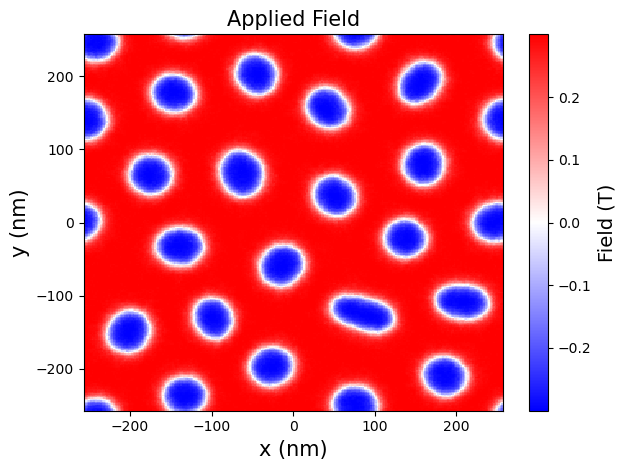

In [2]:
import sys
#!{sys.executable} -m pip install numpy
#!{sys.executable} -m pip install matplotlib
import os
import numpy as np
import matplotlib.pyplot as plt
CURRENT_DIRECTORY = os.path.dirname(os.getcwd())
items = os.listdir(CURRENT_DIRECTORY)
print("Files and Folders:", items)
DATA_AND_LAYER_NAME = "0000_full_mag_40mT_layer2.npy"
DEMAG_B_Z_FILEPATH = os.path.join("Documents/GitHub/sup-spin/mumax3/kaiyang/Fe3Co7_Big3.out", "%s" % DATA_AND_LAYER_NAME)
DEMAG_B_Z = np.load("Documents/GitHub/sup-spin/mumax3/kaiyang/Fe3Co7.out/0004_full_mag_90mT_layer2.npy")
APPLIED_B_Z = 0
B_Z = (DEMAG_B_Z + APPLIED_B_Z)*0.3
# Define coordinates matching the 250x250 grid
grid_size = 256
x_range = np.linspace(-256, 256, grid_size)  # X coordinates (-250 to 250)
y_range = np.linspace(-256, 256, grid_size)  # Y coordinates (-250 to 250)
#plt.figure(figsize=(8, 6))
# Create meshgrid for visualization
X, Y = np.meshgrid(x_range, y_range)
plt.pcolormesh(X, Y, B_Z, cmap="bwr")
#plt.pcolormesh(B_Z, cmap="bwr")
plt.xlabel("x (nm)",fontsize = 15)
plt.ylabel("y (nm)",fontsize = 15)
plt.title("Applied Field",fontsize=15)
#plt.clim(-0.30, 0.30)
cbar = plt.colorbar()
cbar.set_label("Field (T)", fontsize=14)
plt.tight_layout()

/opt/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:733: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


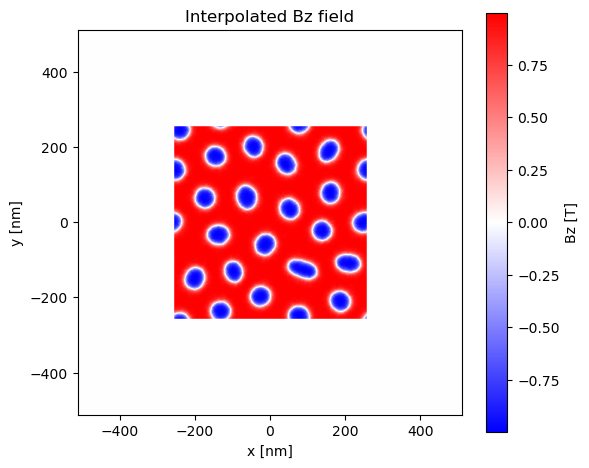

In [86]:
from scipy import interpolate
import pint

ureg = pint.UnitRegistry()
Bz = np.load("Documents/GitHub/sup-spin/mumax3/kaiyang/Fe3Co7.out/0004_full_mag_90mT_layer2.npy")
x = np.linspace(-512, 512, 512)
y = np.linspace(-512, 512, 512)
X, Y = np.meshgrid(x, y)
positions = np.stack([X.ravel(), Y.ravel(), np.zeros_like(X).ravel()], axis=1)

xy_vals = positions[:, :2]
    
# Calculate the range (peak-to-peak) of x and y values
dx = np.ptp(xy_vals[:, 0])
dy = np.ptp(xy_vals[:, 1])
# Calculate the center point for x and y
center_x = np.min(xy_vals[:, 0]) + dx / 2
center_y = np.min(xy_vals[:, 1]) + dy / 2
center = np.array([center_x, center_y])
# Subtract the center point from all xy values to center the data
xy_vals_centered = xy_vals - center
centered_xs = xy_vals_centered[:, 0]
centered_ys = xy_vals_centered[:, 1]
flattened_Bz_values = np.reshape(Bz, (np.shape(Bz)[0] * np.shape(Bz)[1], 1))
# Changes
m = Bz.shape[0]  # should be 256
grid_x = np.linspace(-256, 256, m)
grid_y = np.linspace(-256, 256, m)
X, Y = np.meshgrid(grid_x, grid_y)
interpolated_Bz = interpolate.griddata(
    points = np.vstack([X.ravel(), Y.ravel()]).T,
    values = flattened_Bz_values,
    xi = xy_vals_centered,
    method = "linear",
    fill_value = 0.0,  # <- sets Bz=0 outside the grid
)

interpolated_Bz = interpolated_Bz*ureg("tesla")
centered_ys = centered_ys*ureg("meter")
centered_xs = centered_xs*ureg("meter")
Axy = 1/2*interpolated_Bz * np.stack([-1*centered_ys, centered_xs], axis=1)
# Add z = 0 component
A = np.hstack([Axy, np.zeros_like(Axy[:, :1])])
A = A.to("tesla * meter")

import matplotlib.pyplot as plt

grid_size = int(np.sqrt(len(interpolated_Bz)))  # assume square grid
Bz_image = interpolated_Bz.reshape((grid_size, grid_size))

plt.figure(figsize=(6, 5))
plt.imshow(Bz_image, extent=[-512, 512, -512, 512], origin='lower', cmap='bwr')
plt.colorbar(label='Bz [T]')
plt.title('Interpolated Bz field')
plt.xlabel('x [nm]')
plt.ylabel('y [nm]')
plt.tight_layout()
plt.show()

In [16]:
# B_y
DATA_AND_LAYER_NAME = "B_demag_75mT_0K_layer2"
DEMAG_B_Y_FILEPATH = os.path.join(CURRENT_DIRECTORY, "mumax_fields", "%s_y.npy" % DATA_AND_LAYER_NAME)
DEMAG_B_Y = np.load(DEMAG_B_Y_FILEPATH)
APPLIED_B_Y = 0
B_Y = DEMAG_B_Y + APPLIED_B_Y

FileNotFoundError: [Errno 2] No such file or directory: '/Users/mumax_fields/B_demag_75mT_0K_layer2_y.npy'

Text(0.5, 1.0, 'B_y (T) under +125 mT external field')

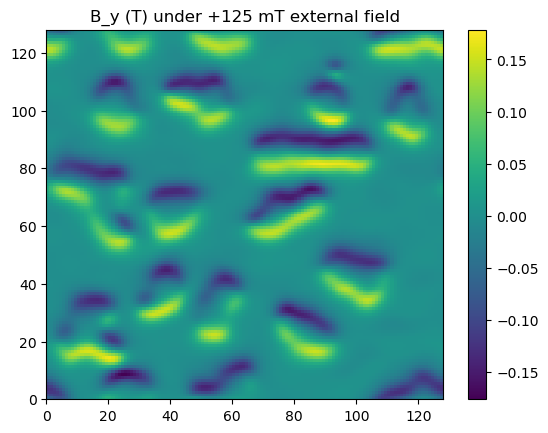

In [6]:
plt.pcolormesh(B_Y, cmap="viridis")
plt.colorbar()
plt.title("B_y (T) under +125 mT external field")


In [7]:
# B_X
DATA_AND_LAYER_NAME = "B_demag_75mT_0K_layer2"
DEMAG_B_X_FILEPATH = os.path.join(CURRENT_DIRECTORY, "mumax_fields", "%s_x.npy" % DATA_AND_LAYER_NAME)
DEMAG_B_X = np.load(DEMAG_B_X_FILEPATH)
APPLIED_B_X = 0
B_X = DEMAG_B_X + APPLIED_B_X

Text(0.5, 1.0, 'B_x (T) under +125 mT external field')

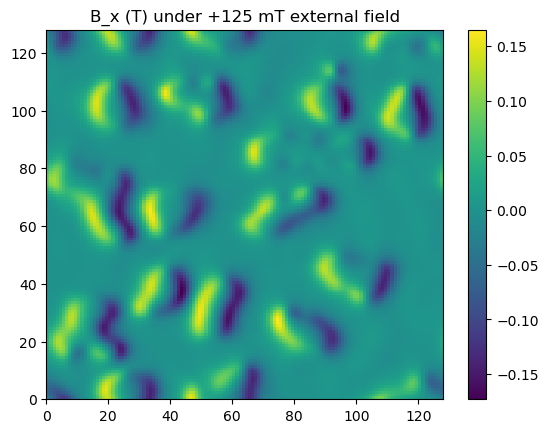

In [8]:
plt.pcolormesh(B_X, cmap="viridis")
plt.colorbar()
plt.title("B_x (T) under +125 mT external field")
